#**Maestría en Inteligencia Artificial Aplicada**

##**Curso: Inteligencia Artificial y Aprendizaje Automático**

###Tecnológico de Monterrey

###Prof Luis Eduardo Falcón Morales

## **Adtividad de las Semanas 5 y 6**
###**Problema de asignación de créditos: South German Dataset.**

## **Nombre y matrícula:**
*  Oscar Ponce
*  A01795164

https://www.kaggle.com/code/prakharprasad/south-german-credit-risk-prediction

# **Parte I: Partición, análisis y pre-procesamiento de los datos.**

## **Ejercicio 1**

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler,OneHotEncoder,OrdinalEncoder,MinMaxScaler

from sklearn.model_selection import RepeatedStratifiedKFold,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,make_scorer,accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')


In [37]:
# Cargamos los datos:

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MNA/AI&ML/semana5-6/SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [38]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:

# ************* Inlcuye aquí tu código:*****************************

#traducciones de codetable.txt
traduccion = {
    'laufkont': 'status',
    'laufzeit': 'duration',
    'moral': 'credit_history',
    'verw': 'purpose',
    'hoehe': 'amount',
    'sparkont': 'savings',
    'beszeit': 'employment_duration',
    'rate': 'installment_rate',
    'famges': 'personal_status_sex',
    'buerge': 'other_debtors',
    'wohnzeit': 'present_residence_since',
    'verm': 'property',
    'alter': 'age',
    'weitkred': 'other_installment_plans',
    'wohn': 'housing',
    'bishkred': 'number_credits',
    'beruf': 'job',
    'pers': 'people_liable',
    'telef': 'telephone',
    'gastarb': 'foreign_worker',
    'kredit': 'credit_risk'
}


df.rename(columns=traduccion, inplace=True)


# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


## **Ejercicio 2**

In [39]:
# Los datos originales tienen en la variable de salida "credit_risk" a la clase negativa (buen cliente) con el valor de 1
# y a la clase de interés positiva (mal cliente) con el valor de 0. Realiza a continuación una transformación para que la
# clase negativa (buen cliente) quede ahora con el valor de 0 y la clase positiva (mal cliente) quede con el valor de 1.

# ************* Inlcuye aquí tu código:*****************************
print('Previo Tranformacion')
print(df['credit_risk'].value_counts())
df['credit_risk'] = df['credit_risk'].apply(lambda x: 0 if x == 1 else 1)
print('\nDespues Tranformacion')
# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

Previo Tranformacion
1    700
0    300
Name: credit_risk, dtype: int64

Despues Tranformacion
0    700
1    300
Name: credit_risk, dtype: int64


## **Ejercicio 3**

In [40]:
# Realiza una partición de 70-15-15 en entrenamiento, validación y prueba.
# Los nombres de los conjuntos deberán ser como se indican en los print de abajo:

# ************* Inlcuye aquí tu código:*****************************
X = df.drop(columns=['credit_risk'],axis=1)
y = df['credit_risk']

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y,train_size=0.7, shuffle=True, random_state=42,  stratify=y)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, train_size=0.5, shuffle=True,stratify=ytv)


# *********** Aquí termina la sección de agregar código *************

# Mostremos las dimensiones de la partición generada:
print(Xtrain.shape, ytrain.shape)
print(Xval.shape, yval.shape)
print(Xtest.shape, ytest.shape)

(700, 20) (700,)
(150, 20) (150,)
(150, 20) (150,)


## **Ejercicio 4**

La tabla 3 del articulo de los recursos de apoyo se menciona la informacion de cada variable y los niveles los encontramos en el archivo codetable.txt. Haremos la validacion de dicho punto.

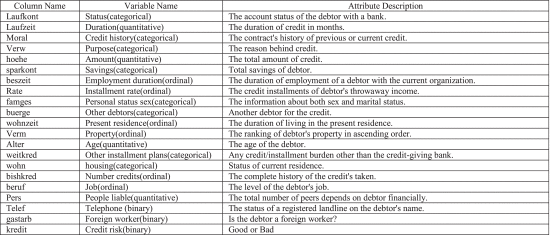


In [41]:
Xtrain.nunique()

status                       4
duration                    31
credit_history               5
purpose                     10
amount                     662
savings                      5
employment_duration          5
installment_rate             4
personal_status_sex          4
other_debtors                3
present_residence_since      4
property                     4
age                         53
other_installment_plans      3
housing                      3
number_credits               4
job                          4
people_liable                2
telephone                    2
foreign_worker               2
dtype: int64

### **Describe a continuación la información de cada variable: su descripción, el tipo de variable y para el caso de las categóricas, el total de niveles que tiene.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

### **Variables Categóricas:**

1.   status niveles:4
2.   credit_history  niveles:5
3.   purpose  niveles: 10
4.   savings  niveles:5
5.   employment_duration niveles: 5 (ordinal)
6.   installment_rate  niveles: 4 (ordinal)
7.   personal_status_sex niveles: 4
8.   other_debtors niveles: 3
9.   present_residence_since niveles: 4 (ordinal)
10.  property nivels: 4 (ordinal)
11.  other_installment_plans niveles: 3
12.  housing  niveles: 3
13.  number_credits niveles: 4  (ordinal)
14.  job  niveles: 4  (ordinal)


### **Variables Numéricas:**

1.   duration
2.   amount
3.   age
4.   people_liable
5.   telephone (binaria)
5.   foreign_worker (binaria)
6.   credit_risk (binaria)

### ++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

In [42]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700 entries, 97 to 549
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   700 non-null    int64
 1   duration                 700 non-null    int64
 2   credit_history           700 non-null    int64
 3   purpose                  700 non-null    int64
 4   amount                   700 non-null    int64
 5   savings                  700 non-null    int64
 6   employment_duration      700 non-null    int64
 7   installment_rate         700 non-null    int64
 8   personal_status_sex      700 non-null    int64
 9   other_debtors            700 non-null    int64
 10  present_residence_since  700 non-null    int64
 11  property                 700 non-null    int64
 12  age                      700 non-null    int64
 13  other_installment_plans  700 non-null    int64
 14  housing                  700 non-null    int64
 15  numbe

In [43]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
status,700.0,2.580000,1.262715,1.0,1.0,2.0,4.00,4.0
duration,700.0,20.761429,12.055734,4.0,12.0,18.0,24.00,72.0
credit_history,700.0,2.515714,1.081002,0.0,2.0,2.0,4.00,4.0
purpose,700.0,2.735714,2.617785,0.0,1.0,2.0,3.00,10.0
amount,700.0,3212.212857,2799.137772,250.0,1373.5,2278.5,3877.25,18424.0
savings,700.0,2.121429,1.579862,1.0,1.0,1.0,3.00,5.0
employment_duration,700.0,3.434286,1.234910,1.0,3.0,3.0,5.00,5.0
installment_rate,700.0,2.977143,1.129418,1.0,2.0,3.0,4.00,4.0
personal_status_sex,700.0,2.664286,0.711752,1.0,2.0,3.0,3.00,4.0
other_debtors,700.0,1.132857,0.454896,1.0,1.0,1.0,1.00,3.0


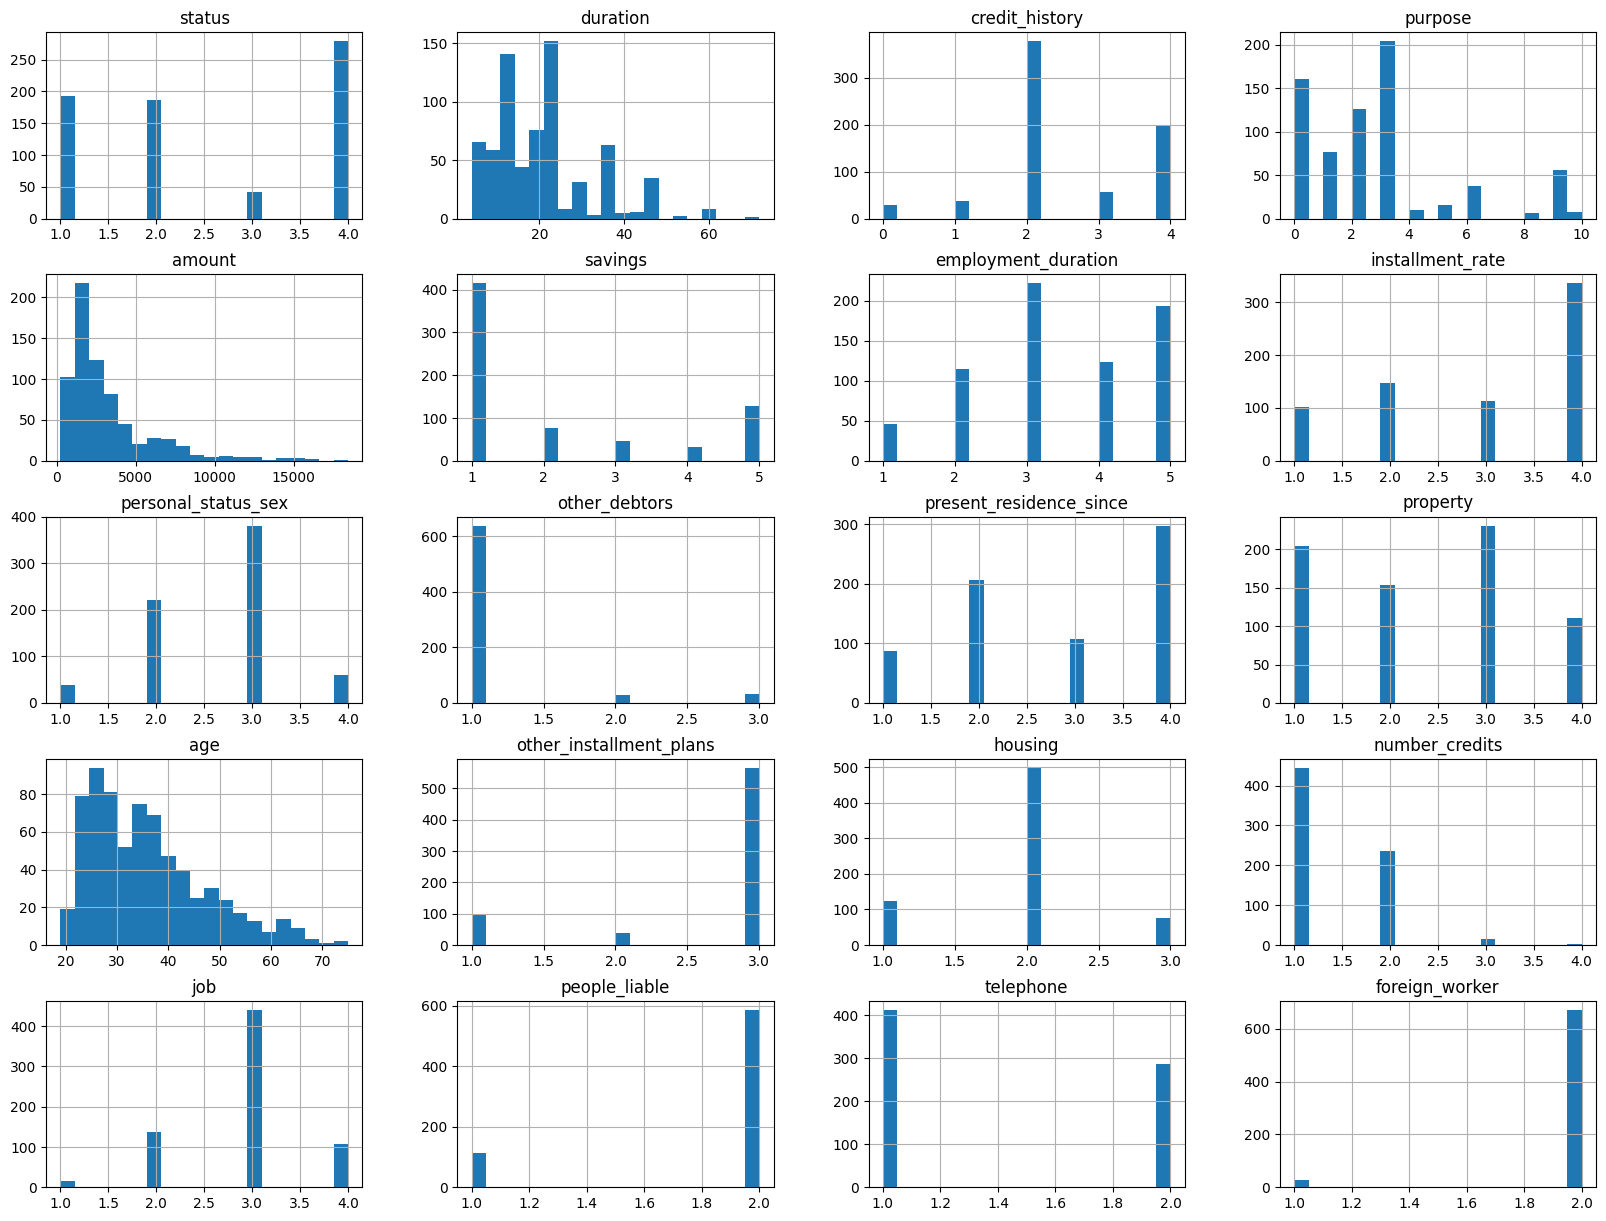

In [44]:
Xtrain.hist(figsize=(20, 15), bins=20)
plt.show()

In [45]:
credit_risk = pd.Series(ytrain).value_counts(normalize=True)
credit_risk

0    0.7
1    0.3
Name: credit_risk, dtype: float64


### **Describe y explica a continuación las transformaciones que has decidido aplicar a cada columna:**

### ++++++++ Inicia la sección de agregar texto: +++++++++++


*   **Numericas:** Se observa un sesgo hacia la derecha. Se usara Yeo-Johnson y Standar Scaler
*   **Categoricas Nominales:** Se usara un One-Hot Encoding. Esto con el fin de que los modelos no confundan las numeros como valore ordinales.

Para las categoricas ordinales y binarias las podemos dejar como estan.


### ++++++++ Termina la sección de agregar texto. +++++++++++


# **Parte II: Modelos de aprendizaje automático con los conjuntos originales de la partición realizada.**

## **Ejercicio 6**

In [46]:
# Transformaciones que se aplicarán a las variables numéricas usando la clase Pipeline de sklearn:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
#TODO: Jugar con las transformaciones numericar a min-max

num_pipe = Pipeline(steps=[('yeo_johnson', PowerTransformer(method='yeo-johnson')),
                           ('scaler', StandardScaler())
])
num_pipe_nombres =  ['duration', 'amount']

num_pipe_age = Pipeline(steps=[('scaler', StandardScaler())])

num_pipe_nombres_age =  ['age']

#Se probo sin mayores diferencias
# num_pipe = Pipeline(steps=[('minmaxscaler', MinMaxScaler())])
# num_pipe_nombres =  ['duration', 'amount','age']

# Variables categóricas+binaria:
cat_pipe = Pipeline(steps = [('catohe', OneHotEncoder(sparse_output=False, drop='first',handle_unknown='ignore'))])
cat_pipe_nombres = ['status', 'credit_history', 'purpose', 'savings',
                    'personal_status_sex', 'other_debtors',
                    'other_installment_plans', 'housing','telephone','foreign_worker']
#Ordinales
ord_pipe = Pipeline(steps = [('ordtrasnf', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])
ord_pipe_nombres = ['employment_duration','installment_rate',
                    'present_residence_since','property','number_credits','job']


# Conjuntemos las transformaciones de todo tipo de variable y en dado caso
# deja inaletardas aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers = [('numpipe', num_pipe, num_pipe_nombres),
                                                        ('numpipe_age', num_pipe_age, num_pipe_nombres_age),
                                                        ('catpipe', cat_pipe, cat_pipe_nombres),
                                                        ('ordpipe', ord_pipe, ord_pipe_nombres)
                                                       ],
                                        remainder='passthrough'   # si hubiera más varaibles que no queremos procesar.
                                       )

# *********** Aquí termina la sección de agregar código *************




## **Ejercicio 7**

In [47]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento y validación
# en uno nuevo aumentado que llamaremos trainval para utilizar como entrenamiento:

# ************* Inlcuye aquí tu código:**************************

# Xtrainval = pd.concat([Xtrain, Xval],axis=o)
Xtrainval = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval = pd.concat([ytrain, yval], ignore_index=True)

# *********** Aquí termina la sección de agregar código *************


print(Xtrainval.shape, ytrainval.shape)

(850, 20) (850,)


## **Ejercicio 8**

In [48]:
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Por el momento todas tienen sus argumentos predeterminados, pero deberás
# ajustarlos de manera que todos los modelos converjan durante el entrenamiento
# y puedas comparar cuál o cuáles de ellos son los mejores modelos.

def mis_modelos():
  modelos, nombres = list(), list()


  # ************* Inlcuye aquí tu código:**************************
  #
  # Deberás incluir en cada modelo los argumentos que consideres
  # adecuados para que cada uno converja. En dado caso una decisión
  # puede ser que un modelo tenga simplemente los valores de sus
  # hiperparámetros con los predeterminados.
  # Consulta en dado caso la documentación de cada modelo para
  # la identificación de los hiperparámetros que desees ajustar.


  # Regresión Logística:
  params_logReg = {
    'C': 1,
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    }

  modelos.append(LogisticRegression(**params_logReg, max_iter=1000 ))
  nombres.append('LR')

  # # k-Vecinos más Cercanos:
  params_knn = {  'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  modelos.append(KNeighborsClassifier(**params_knn))
  nombres.append('kNN')

  # Árbol de decisiones:
  params_dt = { 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
  modelos.append(DecisionTreeClassifier(**params_dt))
  nombres.append('DTree')

  # Bosque Aleatorio:
  params_rf = { 'n_estimators': 100,'max_depth': 4, 'max_features' : 'sqrt','min_samples_split':5 }
  modelos.append(RandomForestClassifier(**params_rf))
  nombres.append('RF')


  # XGBoosting:
  params_xb = { 'colsample_bytree': 0.8,'gamma': 1,'learning_rate': 0.05,
    'max_depth': 2,
    'n_estimators': 50,
    'subsample': 0.8,
    'n_jobs': -1,
    'lambda': 1,
    }

  modelos.append(XGBClassifier(**params_xb, use_label_encoder=False) )
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  params_mlp  = { 'hidden_layer_sizes': (4),'activation': 'logistic', 'alpha':0.0001, }
  modelos.append(MLPClassifier(**params_mlp, max_iter=3000,random_state=42))
  nombres.append('MLP')

  # # Máquina de Vectores de Soporte:
  params_svc  = { 'C': 1.0,'kernel': 'rbf', 'gamma' :'scale' }
  modelos.append(SVC( **params_svc ))
  nombres.append('SVM')

#   # *********** Aquí termina la sección de agregar código *************

  return modelos, nombres






# Entrenemos cada uno de los modelos y desplegamos la métricas de Train y Val.

# NOTA: Observa que el método de Validación-Cruzada llama  a los resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y los modelos:
  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])

  # Aplicaremos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  # Definimos las métricas que desamos recuperar:
  mismetricas = {'accuracy','precision','recall','f1','roc_auc'}

  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtrainval,
                          ytrainval,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelopara análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_precision 0.621 (0.051)
	 train_precision 0.700 (0.019)
	 test_roc_auc 0.791 (0.038)
	 train_roc_auc 0.843 (0.009)
	 test_recall 0.497 (0.062)
	 train_recall 0.559 (0.017)
	 test_f1 0.551 (0.054)
	 train_f1 0.622 (0.017)
	 test_accuracy 0.758 (0.024)
	 train_accuracy 0.796 (0.009)
>> kNN
	 test_precision 0.610 (0.093)
	 train_precision 0.688 (0.037)
	 test_roc_auc 0.756 (0.029)
	 train_roc_auc 0.812 (0.010)
	 test_recall 0.311 (0.067)
	 train_recall 0.353 (0.033)
	 test_f1 0.409 (0.075)
	 train_f1 0.466 (0.033)
	 test_accuracy 0.733 (0.027)
	 train_accuracy 0.758 (0.012)
>> DTree
	 test_precision 0.436 (0.122)
	 train_precision 0.617 (0.087)
	 test_roc_auc 0.696 (0.030)
	 train_roc_auc 0.801 (0.008)
	 test_recall 0.465 (0.245)
	 train_recall 0.576 (0.239)
	 test_f1 0.429 (0.192)
	 train_f1 0.544 (0.143)
	 test_accuracy 0.685 (0.036)
	 train_accuracy 0.746 (0.012)
>> RF
	 test_precision 0.701 (0.186)
	 train_precision 0.971 (0.033)
	 test_roc_auc 0.775 (0.034)
	 train_roc_a

## **Ejercicio 9**

### **De acuerdo a la información de la matriz de costo dada en la documentación del problema, contesta las siguientes preguntas:**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

a.   ¿Qué error se considera más costoso por parte del banco? ¿FP o FN? Justifica tu respuesta.

De acuerdo a la data 1 representa un mal credito y 0 uno bueno. El bueno credito es a quien se le va a dar un prestamo con buenas probabilidades de que se cumplan los pagos. Por eso considero que los falsos negativos, buenos clientes que en realidad no lo son deberia ser la metrica a observar y cuidar.

b.   ¿Cuál o cuál serían entonces las métricas a considerar como más importantes? Justifica tu respuesta.

En base a los descrito arriba el recall deberia ser la metrica a considerar

c.   Investiga qué otras métricas se pudieran considerar, de la gran familia de métricas que existen.

No se debe perder de vista el accuracy, buscaremos subir el recall sin sacrificar tanto el accuracy.

### ++++++++ Termina la sección de agregar texto. +++++++++++


## **Ejercicio 10**

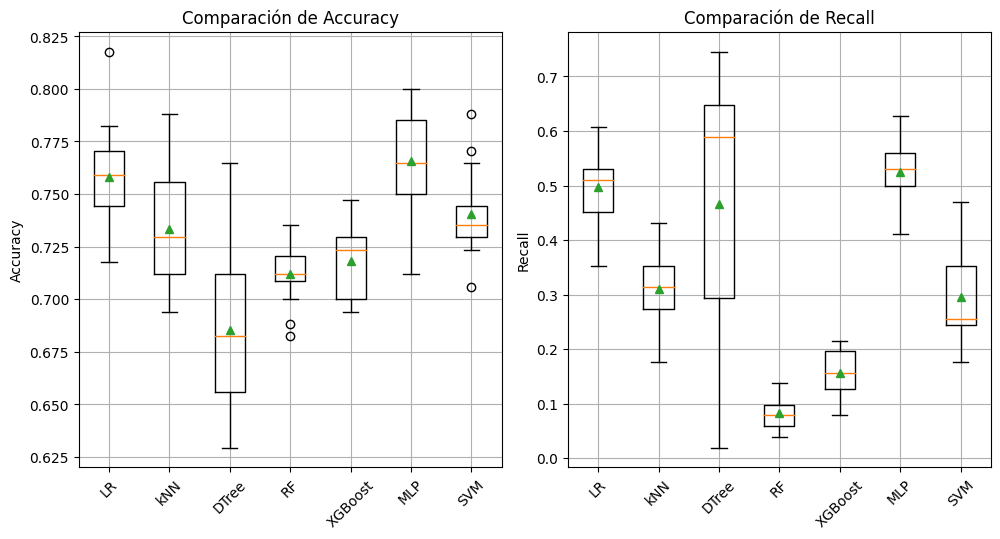

In [49]:
# Obtener un diagrama de caja y bigotes (boxplot) múltiple de todos los modelos,
# utilizando los resultados obtenidos con la métrica que consideraste más importante
# en el ejercicio anterior:


# ************* Inlcuye aquí tu código:**************************



# mismetricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
mismetricas = ['accuracy',  'recall', ]

# Inicializar una figura de matplotlib para contener todos los boxplots
plt.figure(figsize=(15, 10))

# Crear un boxplot para cada métrica
for i, metric in enumerate(mismetricas, start=1):
    # Inicializar una lista para almacenar los scores de la métrica actual
    metric_scores = [resultados[j]['test_' + metric] for j in range(len(modelos))]

    # Crear un subplot para cada métrica
    plt.subplot(2, 3, i)
    plt.boxplot(metric_scores, labels=nombres, showmeans=True)
    plt.title('Comparación de ' + metric.capitalize())
    plt.xticks(rotation=45)
    plt.ylabel(metric.capitalize())
    plt.grid(True)


# Ajustar el layout para evitar la superposición
plt.tight_layout()
plt.show()

# *********** Aquí termina la sección de agregar código *************


# **Parte III: Modelos con técnicas para clases no balanceadas.**

## **Ejercicio 11**

### Submuestreo
Revisando el documento la tecnica de submuestro que mejores resultados dio fue la Random Undersampling. Propuesto en la tabla 10 del paper que acompaña esta tarea.

In [50]:
#https://towardsdatascience.com/the-right-way-of-using-smote-with-cross-validation-92a8d09d00c7
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.under_sampling import RandomUnderSampler

Xtrainval_under = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_under = pd.concat([ytrain, yval], ignore_index=True)

undersampler = RandomUnderSampler(random_state=42)

X_randunder , y_randunder = undersampler.fit_resample(Xtrainval_under,ytrainval_under)

def mis_modelos():
  modelos, nombres = list(), list()


  # ************* Inlcuye aquí tu código:**************************
  #
  # Deberás incluir en cada modelo los argumentos que consideres
  # adecuados para que cada uno converja. En dado caso una decisión
  # puede ser que un modelo tenga simplemente los valores de sus
  # hiperparámetros con los predeterminados.
  # Consulta en dado caso la documentación de cada modelo para
  # la identificación de los hiperparámetros que desees ajustar.


  # Regresión Logística:
  params_logReg = {
    'C': 1,
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    }

  modelos.append(LogisticRegression(**params_logReg, max_iter=1000 ))
  nombres.append('LR')

  # # k-Vecinos más Cercanos:
  params_knn = {  'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  modelos.append(KNeighborsClassifier(**params_knn))
  nombres.append('kNN')

  # Árbol de decisiones:
  params_dt = { 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
  modelos.append(DecisionTreeClassifier(**params_dt))
  nombres.append('DTree')

  # Bosque Aleatorio:
  params_rf = { 'n_estimators': 100,'max_depth': 4, 'max_features' : 'sqrt','min_samples_split':5 }
  modelos.append(RandomForestClassifier(**params_rf))
  nombres.append('RF')


  # XGBoosting:
  params_xb = { 'colsample_bytree': 0.8,'gamma': 1,'learning_rate': 0.05,
    'max_depth': 2,
    'n_estimators': 50,
    'subsample': 0.8,
    'n_jobs': -1,
    'lambda': 1,
    }

  modelos.append(XGBClassifier(**params_xb, use_label_encoder=False) )
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  params_mlp  = { 'hidden_layer_sizes': (4),'activation': 'logistic', 'alpha':0.0001, }
  modelos.append(MLPClassifier(**params_mlp, max_iter=3000,random_state=42))
  nombres.append('MLP')

  # # Máquina de Vectores de Soporte:
  params_svc  = { 'C': 1.0,'kernel': 'rbf', 'gamma' :'scale' }
  modelos.append(SVC( **params_svc ))
  nombres.append('SVM')

#   # *********** Aquí termina la sección de agregar código *************

  return modelos, nombres






# Entrenemos cada uno de los modelos y desplegamos la métricas de Train y Val.

# NOTA: Observa que el método de Validación-Cruzada llama  a los resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y los modelos:
  pipeline = imbpipeline(steps=[('ct',columnasTransformer),
                                 ('m',modelos[i])])

  # Aplicaremos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  # Definimos las métricas que desamos recuperar:
  mismetricas = {'accuracy','precision','recall','f1','roc_auc'}

  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          X_randunder,
                          y_randunder,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelopara análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s Random Under' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR Random Under
	 test_precision 0.723 (0.036)
	 train_precision 0.787 (0.016)
	 test_roc_auc 0.798 (0.051)
	 train_roc_auc 0.856 (0.011)
	 test_recall 0.720 (0.079)
	 train_recall 0.773 (0.014)
	 test_f1 0.720 (0.051)
	 train_f1 0.780 (0.012)
	 test_accuracy 0.722 (0.043)
	 train_accuracy 0.782 (0.012)
>> kNN Random Under
	 test_precision 0.648 (0.030)
	 train_precision 0.687 (0.013)
	 test_roc_auc 0.756 (0.045)
	 train_roc_auc 0.807 (0.010)
	 test_recall 0.756 (0.045)
	 train_recall 0.794 (0.016)
	 test_f1 0.697 (0.033)
	 train_f1 0.737 (0.011)
	 test_accuracy 0.673 (0.034)
	 train_accuracy 0.716 (0.013)
>> DTree Random Under
	 test_precision 0.647 (0.052)
	 train_precision 0.733 (0.046)
	 test_roc_auc 0.705 (0.032)
	 train_roc_auc 0.817 (0.014)
	 test_recall 0.663 (0.123)
	 train_recall 0.757 (0.104)
	 test_f1 0.644 (0.064)
	 train_f1 0.737 (0.038)
	 test_accuracy 0.643 (0.036)
	 train_accuracy 0.735 (0.015)
>> RF Random Under
	 test_precision 0.694 (0.036)
	 train_precision 0.77

### Sobremuestreo
Revisando el documento la tecnica de sobremuestro que mejores resultados dio fue la KMeansSMOTE. Propuesto en la tabla 12 del paper que acompaña esta tarea.

In [51]:
resultadosKmeansSmote = list()
resultadosSmote = list()
resultadossMOTETomek = list()

In [52]:
from imblearn.over_sampling import KMeansSMOTE
from sklearn.cluster import MiniBatchKMeans

Xtrainval_over = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_over = pd.concat([ytrain, yval], ignore_index=True)

oversample = KMeansSMOTE(kmeans_estimator=MiniBatchKMeans(n_init='auto', random_state=42),random_state=42)

X_kmsmote, y_kmsmote = oversample.fit_resample(Xtrainval_over,ytrainval_over)
def mis_modelos():
  modelos, nombres = list(), list()


  # ************* Inlcuye aquí tu código:**************************
  #
  # Deberás incluir en cada modelo los argumentos que consideres
  # adecuados para que cada uno converja. En dado caso una decisión
  # puede ser que un modelo tenga simplemente los valores de sus
  # hiperparámetros con los predeterminados.
  # Consulta en dado caso la documentación de cada modelo para
  # la identificación de los hiperparámetros que desees ajustar.


  # Regresión Logística:
  params_logReg = {
    'C': 1,
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    }

  modelos.append(LogisticRegression(**params_logReg, max_iter=1000 ))
  nombres.append('LR')

  # # k-Vecinos más Cercanos:
  params_knn = {  'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  modelos.append(KNeighborsClassifier(**params_knn))
  nombres.append('kNN')

  # Árbol de decisiones:
  params_dt = { 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
  modelos.append(DecisionTreeClassifier(**params_dt))
  nombres.append('DTree')

  # Bosque Aleatorio:
  params_rf = { 'n_estimators': 100,'max_depth': 4, 'max_features' : 'sqrt','min_samples_split':5 }
  modelos.append(RandomForestClassifier(**params_rf))
  nombres.append('RF')


  # XGBoosting:
  params_xb = {
    'colsample_bytree': 0.8,
    'gamma': 5,  # Aumentado para mejorar la regularización
    'learning_rate': 0.01,  # Disminuido para un aprendizaje más lento y estable
    'max_depth': 4,  # Incrementado ligeramente
    'n_estimators': 200,  # Puedes intentar disminuir si el sobreajuste persiste
    'subsample': 0.8,
    'n_jobs': -1,
    'lambda': 10,  # Aumentado para una regularización más fuerte
    'alpha': 1,  # Regularización L1
    'min_child_weight': 5,  # Aumentado para controlar la profundidad del árbol
    #'early_stopping_rounds': 10  # Añadido early stopping
    }

  modelos.append(XGBClassifier(**params_xb, use_label_encoder=False) )
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  params_mlp  = { 'hidden_layer_sizes': (4),'activation': 'logistic', 'alpha':0.0001, }
  modelos.append(MLPClassifier(**params_mlp, max_iter=3000,random_state=42))
  nombres.append('MLP')

  # # Máquina de Vectores de Soporte:
  params_svc  = { 'C': 1.0,'kernel': 'rbf', 'gamma' :'scale' }
  modelos.append(SVC( **params_svc ))
  nombres.append('SVM')

#   # *********** Aquí termina la sección de agregar código *************

  return modelos, nombres






# Entrenemos cada uno de los modelos y desplegamos la métricas de Train y Val.

# NOTA: Observa que el método de Validación-Cruzada llama  a los resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y los modelos:
  pipeline = Pipeline(steps=[('ct',columnasTransformer),
                                ('m',modelos[i])])
  # pipeline = imbpipeline(steps=[('ct',columnasTransformer),
  #                               ('smote', SMOTE(random_state=42)),
  #                               ('m',modelos[i])])

  # Aplicaremos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  # Definimos las métricas que desamos recuperar:
  mismetricas = {'accuracy','precision','recall','f1','roc_auc'}

  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          X_kmsmote,
                          y_kmsmote,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelopara análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s KmeansSmote' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

resultadosKmeansSmote = resultados

>> LR KmeansSmote
	 test_precision 0.828 (0.027)
	 train_precision 0.846 (0.007)
	 test_roc_auc 0.902 (0.020)
	 train_roc_auc 0.922 (0.004)
	 test_recall 0.809 (0.035)
	 train_recall 0.826 (0.007)
	 test_f1 0.818 (0.024)
	 train_f1 0.836 (0.006)
	 test_accuracy 0.820 (0.023)
	 train_accuracy 0.838 (0.006)
>> kNN KmeansSmote
	 test_precision 0.844 (0.030)
	 train_precision 0.856 (0.006)
	 test_roc_auc 0.894 (0.022)
	 train_roc_auc 0.913 (0.004)
	 test_recall 0.747 (0.037)
	 train_recall 0.762 (0.009)
	 test_f1 0.792 (0.027)
	 train_f1 0.806 (0.007)
	 test_accuracy 0.804 (0.024)
	 train_accuracy 0.817 (0.006)
>> DTree KmeansSmote
	 test_precision 0.886 (0.108)
	 train_precision 0.910 (0.105)
	 test_roc_auc 0.878 (0.017)
	 train_roc_auc 0.904 (0.003)
	 test_recall 0.681 (0.132)
	 train_recall 0.703 (0.131)
	 test_f1 0.752 (0.036)
	 train_f1 0.776 (0.030)
	 test_accuracy 0.780 (0.016)
	 train_accuracy 0.801 (0.007)
>> RF KmeansSmote
	 test_precision 0.912 (0.025)
	 train_precision 0.941 (0

In [53]:
from imblearn.over_sampling import SMOTE
from sklearn.cluster import MiniBatchKMeans

Xtrainval_over = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_over = pd.concat([ytrain, yval], ignore_index=True)

oversample = SMOTE(random_state=42)
X_smote, y_smote = oversample.fit_resample(Xtrainval_over,ytrainval_over)


def mis_modelos():
  modelos, nombres = list(), list()


  # ************* Inlcuye aquí tu código:**************************
  #
  # Deberás incluir en cada modelo los argumentos que consideres
  # adecuados para que cada uno converja. En dado caso una decisión
  # puede ser que un modelo tenga simplemente los valores de sus
  # hiperparámetros con los predeterminados.
  # Consulta en dado caso la documentación de cada modelo para
  # la identificación de los hiperparámetros que desees ajustar.


  # Regresión Logística:
  params_logReg = {
    'C': 1,
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    }

  modelos.append(LogisticRegression(**params_logReg, max_iter=1000 ))
  nombres.append('LR')

  # # k-Vecinos más Cercanos:
  params_knn = {  'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  modelos.append(KNeighborsClassifier(**params_knn))
  nombres.append('kNN')

  # Árbol de decisiones:
  params_dt = { 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
  modelos.append(DecisionTreeClassifier(**params_dt))
  nombres.append('DTree')

  # Bosque Aleatorio:
  params_rf = { 'n_estimators': 100,'max_depth': 4, 'max_features' : 'sqrt','min_samples_split':5 }
  modelos.append(RandomForestClassifier(**params_rf))
  nombres.append('RF')


  # XGBoosting:
  params_xb = {
    'colsample_bytree': 0.8,
    'gamma': 5,  # Aumentado para mejorar la regularización
    'learning_rate': 0.01,  # Disminuido para un aprendizaje más lento y estable
    'max_depth': 4,  # Incrementado ligeramente
    'n_estimators': 200,
    'subsample': 0.8,
    'n_jobs': -1,
    'lambda': 10,  # Aumentado para una regularización más fuerte
    'alpha': 1,  # Regularización L1
    'min_child_weight': 5,  # Aumentado para controlar la profundidad del árbol
    #'early_stopping_rounds': 10  # Añadido early stopping
    }

  modelos.append(XGBClassifier(**params_xb, use_label_encoder=False) )
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  params_mlp  = { 'hidden_layer_sizes': (4),'activation': 'logistic', 'alpha':0.0001, }
  modelos.append(MLPClassifier(**params_mlp, max_iter=3000,random_state=42))
  nombres.append('MLP')

  # # Máquina de Vectores de Soporte:
  params_svc  = { 'C': 1.0,'kernel': 'rbf', 'gamma' :'scale' }
  modelos.append(SVC( **params_svc ))
  nombres.append('SVM')

#   # *********** Aquí termina la sección de agregar código *************

  return modelos, nombres






# Entrenemos cada uno de los modelos y desplegamos la métricas de Train y Val.

# NOTA: Observa que el método de Validación-Cruzada llama  a los resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y los modelos:
  pipeline = Pipeline(steps=[('ct',columnasTransformer),
                                ('m',modelos[i])])
  # pipeline = imbpipeline(steps=[('ct',columnasTransformer),
  #                               ('smote', SMOTE(random_state=42)),
  #                               ('m',modelos[i])])

  # Aplicaremos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  # Definimos las métricas que desamos recuperar:
  mismetricas = {'accuracy','precision','recall','f1','roc_auc'}

  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          X_smote,
                          y_smote,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelopara análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s Smote' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))


resultadosSmote = resultados

>> LR Smote
	 test_precision 0.798 (0.031)
	 train_precision 0.821 (0.008)
	 test_roc_auc 0.881 (0.020)
	 train_roc_auc 0.903 (0.004)
	 test_recall 0.815 (0.027)
	 train_recall 0.834 (0.007)
	 test_f1 0.806 (0.020)
	 train_f1 0.828 (0.006)
	 test_accuracy 0.804 (0.022)
	 train_accuracy 0.826 (0.006)
>> kNN Smote
	 test_precision 0.752 (0.024)
	 train_precision 0.778 (0.009)
	 test_roc_auc 0.873 (0.018)
	 train_roc_auc 0.899 (0.005)
	 test_recall 0.843 (0.027)
	 train_recall 0.860 (0.010)
	 test_f1 0.795 (0.021)
	 train_f1 0.817 (0.005)
	 test_accuracy 0.782 (0.023)
	 train_accuracy 0.807 (0.006)
>> DTree Smote
	 test_precision 0.731 (0.036)
	 train_precision 0.748 (0.013)
	 test_roc_auc 0.800 (0.026)
	 train_roc_auc 0.839 (0.010)
	 test_recall 0.852 (0.033)
	 train_recall 0.870 (0.025)
	 test_f1 0.786 (0.023)
	 train_f1 0.804 (0.007)
	 test_accuracy 0.768 (0.030)
	 train_accuracy 0.788 (0.007)
>> RF Smote
	 test_precision 0.757 (0.022)
	 train_precision 0.786 (0.009)
	 test_roc_auc 0.8

In [54]:
# print(g_mean(y_true, y_pred))

### Combinado
Usando SMOTETomek, le haremos una combinacion

In [55]:
from imblearn.combine import SMOTETomek


Xtrainval_combine = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_combine = pd.concat([ytrain, yval], ignore_index=True)

smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(Xtrainval_combine,ytrainval_combine)


def mis_modelos():
  modelos, nombres = list(), list()


  # ************* Inlcuye aquí tu código:**************************
  #
  # Deberás incluir en cada modelo los argumentos que consideres
  # adecuados para que cada uno converja. En dado caso una decisión
  # puede ser que un modelo tenga simplemente los valores de sus
  # hiperparámetros con los predeterminados.
  # Consulta en dado caso la documentación de cada modelo para
  # la identificación de los hiperparámetros que desees ajustar.


  # Regresión Logística:
  params_logReg = {
    'C': 1,
    'penalty': 'l2',
    'solver': 'liblinear',
    'fit_intercept': True,
    }

  modelos.append(LogisticRegression(**params_logReg, max_iter=1000 ))
  nombres.append('LR')

  # # k-Vecinos más Cercanos:
  params_knn = {  'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
  modelos.append(KNeighborsClassifier(**params_knn))
  nombres.append('kNN')

  # Árbol de decisiones:
  params_dt = { 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
  modelos.append(DecisionTreeClassifier(**params_dt))
  nombres.append('DTree')

  # Bosque Aleatorio:
  params_rf = { 'n_estimators': 100,'max_depth': 4, 'max_features' : 'sqrt','min_samples_split':5 }
  modelos.append(RandomForestClassifier(**params_rf))
  nombres.append('RF')


  # XGBoosting:
  params_xb = {
    'colsample_bytree': 0.8,
    'gamma': 5,  # Aumentado para mejorar la regularización
    'learning_rate': 0.01,  # Disminuido para un aprendizaje más lento y estable
    'max_depth': 4,  # Incrementado ligeramente
    'n_estimators': 200,  # Puedes intentar disminuir si el sobreajuste persiste
    'subsample': 0.8,
    'n_jobs': -1,
    'lambda': 10,  # Aumentado para una regularización más fuerte
    'alpha': 1,  # Regularización L1
    'min_child_weight': 5,  # Aumentado para controlar la profundidad del árbol
    #'early_stopping_rounds': 10  # Añadido early stopping
    }

  modelos.append(XGBClassifier(**params_xb, use_label_encoder=False) )
  nombres.append('XGBoost')

  # Red neuronal de Perceptrón Multicapa:
  params_mlp  = { 'hidden_layer_sizes': (4),'activation': 'logistic', 'alpha':0.0001, }
  modelos.append(MLPClassifier(**params_mlp, max_iter=3000,random_state=42))
  nombres.append('MLP')

  # # Máquina de Vectores de Soporte:
  params_svc  = { 'C': 1.0,'kernel': 'rbf', 'gamma' :'scale' }
  modelos.append(SVC( **params_svc ))
  nombres.append('SVM')

#   # *********** Aquí termina la sección de agregar código *************

  return modelos, nombres






# Entrenemos cada uno de los modelos y desplegamos la métricas de Train y Val.

# NOTA: Observa que el método de Validación-Cruzada llama  a los resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  pipeline = imbpipeline(steps=[('ct',columnasTransformer),
                                ('m',modelos[i])])

  # Aplicaremos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3)

  # Definimos las métricas que desamos recuperar:
  mismetricas = {'accuracy','precision','recall','f1','roc_auc'}

  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          X_res,
                          y_res,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelopara análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s  SMOTETomek' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

resultadossMOTETomek = resultados

>> LR  SMOTETomek
	 test_precision 0.809 (0.034)
	 train_precision 0.830 (0.007)
	 test_roc_auc 0.885 (0.026)
	 train_roc_auc 0.910 (0.006)
	 test_recall 0.823 (0.039)
	 train_recall 0.842 (0.009)
	 test_f1 0.815 (0.029)
	 train_f1 0.836 (0.006)
	 test_accuracy 0.814 (0.029)
	 train_accuracy 0.835 (0.006)
>> kNN  SMOTETomek
	 test_precision 0.744 (0.022)
	 train_precision 0.778 (0.009)
	 test_roc_auc 0.875 (0.016)
	 train_roc_auc 0.905 (0.004)
	 test_recall 0.845 (0.026)
	 train_recall 0.868 (0.008)
	 test_f1 0.791 (0.016)
	 train_f1 0.821 (0.007)
	 test_accuracy 0.776 (0.018)
	 train_accuracy 0.810 (0.008)
>> DTree  SMOTETomek
	 test_precision 0.714 (0.029)
	 train_precision 0.744 (0.012)
	 test_roc_auc 0.802 (0.027)
	 train_roc_auc 0.848 (0.010)
	 test_recall 0.854 (0.030)
	 train_recall 0.890 (0.021)
	 test_f1 0.777 (0.021)
	 train_f1 0.810 (0.006)
	 test_accuracy 0.755 (0.026)
	 train_accuracy 0.791 (0.007)
>> RF  SMOTETomek
	 test_precision 0.763 (0.026)
	 train_precision 0.792 (0

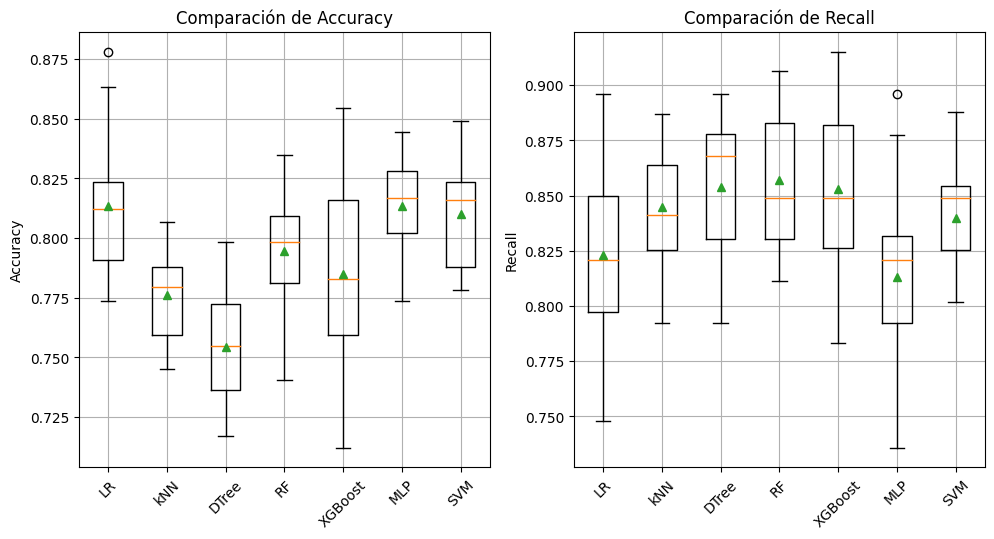

In [56]:
mismetricas = ['accuracy',  'recall', ]

# Inicializar una figura de matplotlib para contener todos los boxplots
plt.figure(figsize=(15, 10))

# Crear un boxplot para cada métrica
for i, metric in enumerate(mismetricas, start=1):
    # Inicializar una lista para almacenar los scores de la métrica actual
    metric_scores = [resultados[j]['test_' + metric] for j in range(len(modelos))]

    # Crear un subplot para cada métrica
    plt.subplot(2, 3, i)
    plt.boxplot(metric_scores, labels=nombres, showmeans=True)
    plt.title('Comparación de ' + metric.capitalize())
    plt.xticks(rotation=45)
    plt.ylabel(metric.capitalize())
    plt.grid(True)


# Ajustar el layout para evitar la superposición
plt.tight_layout()
plt.show()

Referencias:

https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

# **Parte IV: Mejor modelo**

## **Ejercicio 12**

### **Selecciona y justifica cuál consideras es el mejor modelo que has obtenido hasta ahora.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

El mejor modelo es el  XGBoost  SMOTETomek. Viendo la diferente entre train y test menor al 3% . A pesar de que otros modelos tiene un valor mejore valor de accuracy lo veo sobreentrenado y este tiene mejor Recall que tambien es una valor relevante.

### ++++++++ Termina la sección de agregar texto. +++++++++++


## **Ejercicio 13**

In [86]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as imbpipeline

# Preparación de datos
Xtrainval_best = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_best = pd.concat([ytrain, yval], ignore_index=True)

smt = SMOTETomek(random_state=42)
X_best, y_best = smt.fit_resample(Xtrainval_best, ytrainval_best)

# Espacio de búsqueda de hiperparámetros para XGBClassifier
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 4],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 1],
    'subsample': [0.7, 0.8],
    'lambda': [1, 1.5],
    'alpha': [0, 0.5]
}

# Configurar GridSearchCV para XGBClassifier
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    scoring='accuracy',  # Cambiar por la métrica de interés
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    n_jobs=-1,
    verbose=2
)

# Crear un pipeline con SMOTETomek, el transformador y el grid search
pipeline_xgb = imbpipeline(steps=[
    ('ct', columnasTransformer),  # Preprocesamiento
    ('grid_search', grid_search_xgb)  # Búsqueda de hiperparámetros
])

# Entrenar el pipeline
pipeline_xgb.fit(X_best, y_best)

# Mejores parámetros encontrados
print("Mejores parámetros XGB: ", pipeline_xgb.named_steps['grid_search'].best_params_)
print("Mejor puntuación Accuracy XGB: ", pipeline_xgb.named_steps['grid_search'].best_score_)

# Acceder al mejor modelo directamente
mejor_modelo_xgb = pipeline_xgb.named_steps['grid_search'].best_estimator_


Fitting 15 folds for each of 256 candidates, totalling 3840 fits
Mejores parámetros XGB:  {'alpha': 0, 'colsample_bytree': 0.8, 'gamma': 0, 'lambda': 1, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Mejor puntuación Accuracy XGB:  0.8424498774618361


## **Ejercicio 14**

In [98]:
# 14.	Con el mejor modelo y los mejores hiperparámetros encontrados en el ejercicio anterior,
# utiliza ahora (por primera vez en la actividad) el conjunto de prueba (test set) para:

# a.	Obtener los valores de todas las métricas que se han estado desplegando.


# ************* Inlcuye aquí tu código:**************************
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Xtrainval_combine = pd.concat([Xtrain, Xval], ignore_index=True)
ytrainval_combine = pd.concat([ytrain, yval], ignore_index=True)

smt = SMOTETomek(random_state=42)
X_final, y_final = smt.fit_resample(Xtrainval_combine,ytrainval_combine)


xb_params = {'alpha': 0, 'colsample_bytree': 0.8, 'gamma': 0, 'lambda': 1, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
xboost_model  = XGBClassifier(**xb_params)


# Crear el pipeline
pipeline = imbpipeline(steps=[('ct', columnasTransformer),
                              ('xb', xboost_model)],
                       )

# Entrenar el modelo con los datos balanceados por SMOTETomek
pipeline.fit(X_final, y_final)

# Predecir el conjunto de prueba
y_pred = pipeline.predict(Xtest)
y_pred_proba = pipeline.predict_proba(Xtest)[:, 1]

# Calcular métricas de evaluación
accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred)
recall = recall_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)
roc_auc = roc_auc_score(ytest, y_pred_proba)

# Imprimir las métricas
print("Resultados en el conjunto de prueba Xboost-SMOTETomek:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")


Resultados en el conjunto de prueba Xboost-SMOTETomek:
Accuracy: 0.733
Precision: 0.556
Recall: 0.556
F1 Score: 0.556
ROC AUC: 0.784


In [92]:
print("\nClassification Report:\n", classification_report(ytest, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       105
           1       0.56      0.56      0.56        45

    accuracy                           0.73       150
   macro avg       0.68      0.68      0.68       150
weighted avg       0.73      0.73      0.73       150



In [93]:
#b. Obtener la matriz de confusión

conf_matrix_selected = confusion_matrix(ytest, y_pred)
print(conf_matrix_selected)

[[85 20]
 [20 25]]


In [94]:
# c.	Realiza un análisis de importancia de variables (feature importance) de este
# mejor modelo con el conjunto de prueba (test) e incluye tus conclusiones al respecto.

# ************* Inlcuye aquí tu código:**************************

# Accede al modelo XGBClassifier dentro del pipeline
xgb_model = pipeline.named_steps['xb']

# Obtiene la importancia de las características
feature_importances = xgb_model.feature_importances_

# Para obtener los nombres de las características después de la transformación, necesitas el paso 'ct'
# Esto puede ser complicado si la transformación cambia el número de características
# Aquí asumimos que tienes una forma de obtener esos nombres, lo cual varía según la transformación aplicada
transformed_feature_names = pipeline.named_steps['ct'].get_feature_names_out()

# Crear un DataFrame para visualizar la importancia de las características
features_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(features_df)

# *********** Aquí termina la sección de agregar código *************

                               Feature  Importance
5                    catpipe__status_4    0.191653
9            catpipe__credit_history_4    0.071764
23                  catpipe__savings_5    0.039669
32                  catpipe__housing_3    0.039019
29  catpipe__other_installment_plans_2    0.036067
6            catpipe__credit_history_1    0.035598
28            catpipe__other_debtors_3    0.035548
24      catpipe__personal_status_sex_2    0.028754
7            catpipe__credit_history_2    0.027586
33                catpipe__telephone_2    0.024683
30  catpipe__other_installment_plans_3    0.023271
34           catpipe__foreign_worker_2    0.022719
14                  catpipe__purpose_5    0.021841
4                    catpipe__status_3    0.021107
0                    numpipe__duration    0.020750
22                  catpipe__savings_4    0.020315
12                  catpipe__purpose_3    0.019645
18                  catpipe__purpose_9    0.019219
41            remainder__people

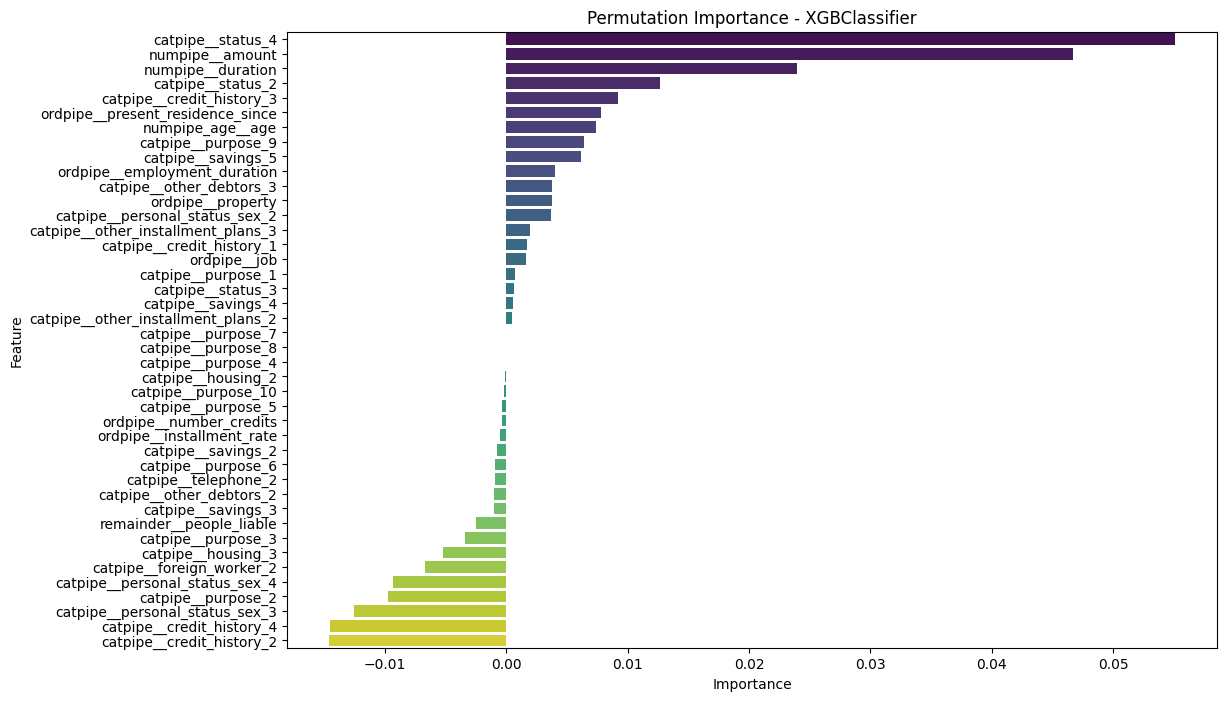

In [97]:
from sklearn.inspection import permutation_importance
# Preprocesa los datos de prueba para transformarlos de acuerdo al pipeline
X_test_transformed = pipeline.named_steps['ct'].transform(Xtest)

# Extrae el modelo XGBClassifier del pipeline
xgb_model = pipeline.named_steps['xb']

# Calcula la importancia de permutación
result = permutation_importance(xgb_model, X_test_transformed, ytest, scoring='f1_weighted', n_repeats=30, random_state=42)

# Para obtener los nombres de las características transformadas, asumiendo que se puede extraer de 'ct'
try:
    feature_names = pipeline.named_steps['ct'].get_feature_names_out()
except AttributeError:  # Si 'get_feature_names_out' no está disponible
    # Suponiendo que tienes una forma de obtener los nombres o usar un rango numérico como sustituto
    feature_names = [str(i) for i in range(X_test_transformed.shape[1])]

# Crea un DataFrame con la importancia y los nombres de las características
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean})

# Ordena el DataFrame por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Grafica la importancia de permutación
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', dodge=False)
plt.title('Permutation Importance - XGBClassifier')
plt.show()


Revisando los resultados se puede notar que las historia crediticia es obviamente muy importante al momento de dar un prestamo. Al igual que la cantidad y el tiempo del mismo. Me llama la atencion que el proposito del credito es irrelevante.

## **Ejercicio 15**

### **Escribe tus conclusiones finales de la actividad. En particular puedes comparar tus resultados con los que se muestran en el artículo de la IEEE.**   

### ++++++++ Inicia la sección de agregar texto: +++++++++++

En conclusion a pesar de que un estudio publicado obtiene unos valores y modelos tratar de replicarlos es dificil. No llegamos a los valores del estudio en su mejor modelo pero si a los valores aproximados de los mejores modelos de machine learning tradicionales. La cantidad de hiperparametros y tecnicas de submuestro, sobremuestro y combinaciones hacen que el trabajo no solo sea dificil de replicar sino que tienen muchisimo prueba y error. A pesar de tener funciones como Gridsearch y Randomsearch, las cantidades de hiperparametros hacen dificil intentar con todos.

Me llama la atencion la baja que se tiene en el accuracy una vez que usamos la data de test. Aqui me queda la duda si existe un error de mi parte o es normal de los modelos a pesar de buscar valores no sobrenetrenado, que cuando la data que nunca se ha visto se baje la exactitud.


### ++++++++ Termina la sección de agregar texto. +++++++++++


>> ###**Fin de la Actividad de las Semanas 5 y 6.**